In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# load theoretical baseline
with open("./results/run_7/46DCB4919A98C1532600B4D7134ECA28/validation_mamba_cnn_150000_instances.json", "r") as f:
    baseline_data = json.load(f)

# load real CIFAR results
with open("./simulation_results/2026-04-14_13-04-45/test_results_model.json", "r") as f:
    cifar_data = json.load(f)

with open("./simulation_results/2026-04-10_19-38-43/test_results_bp.json", "r") as f:
    bp_cifar_data = json.load(f)

In [3]:
baseline_key = list(baseline_data.keys())[0]
baseline = baseline_data[baseline_key]

snr_vals = list(range(-10, 11))

baseline_ber = []
for snr in snr_vals:
    key = f"BER_{snr}"
    baseline_ber.append(baseline.get(key, None))

In [4]:
import numpy as np

def shannon_limit_db(rate):
    snr = (2**rate - 1) / rate
    ebn0_db = 10 * np.log10(snr)
    return ebn0_db

In [5]:
baseline_key = list(baseline_data.keys())[0]
baseline = baseline_data[baseline_key]

snr_vals = list(range(-10, 11))

baseline_ber = []
for snr in snr_vals:
    key = f"BER_{snr}"
    baseline_ber.append(baseline.get(key, None))

In [6]:
cifar_ber = []

for snr in snr_vals:
    key = f"snr_{snr}_00"
    val = cifar_data["overall_metrics"].get(key, {}).get("average_BER", None)
    cifar_ber.append(val)

In [7]:
bp_cifar_ber = []

for snr in snr_vals:
    key = f"snr_{snr}_00"
    val = bp_cifar_data["overall_metrics"].get(key, {}).get("average_BER", None)
    bp_cifar_ber.append(val)

In [8]:
shannon_db = shannon_limit_db(0.5)

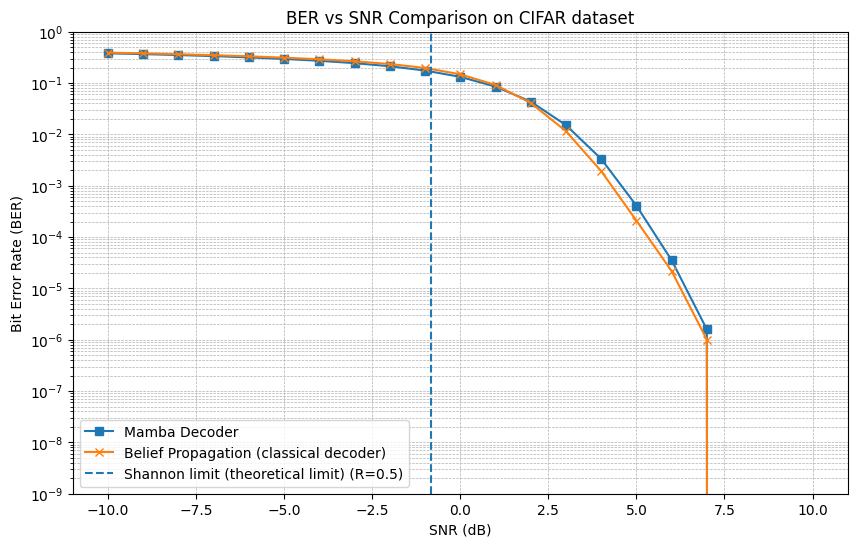

In [11]:
plt.figure(figsize=(10,6))


plt.plot(snr_vals, cifar_ber, marker='s', label="Mamba Decoder")
plt.plot(snr_vals, bp_cifar_ber, marker='x', label="Belief Propagation (classical decoder)")

plt.ylim(1e-9, 1)   
plt.axvline(
    shannon_db,
    linestyle="--",
    label=f"Shannon limit (theoretical limit) (R=0.5)"
)
plt.yscale("log")
plt.xlabel("SNR (dB)")
plt.ylabel("Bit Error Rate (BER)")
plt.title("BER vs SNR Comparison on CIFAR dataset")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()

plt.show()

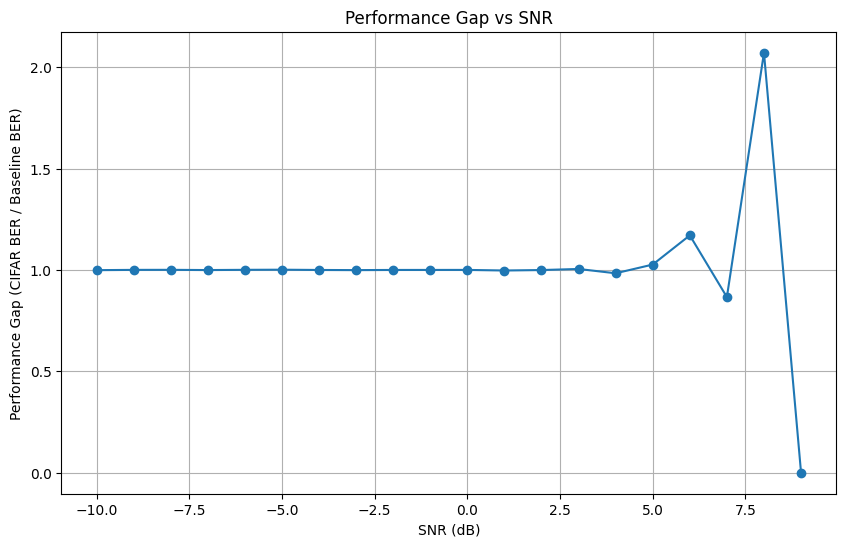

In [9]:
gap = []

for b, c in zip(baseline_ber, cifar_ber):
    if b is not None and c is not None and b != 0:
        gap.append(c / b)
    else:
        gap.append(None)

plt.figure(figsize=(10,6))
plt.plot(snr_vals, gap, marker='o')

plt.xlabel("SNR (dB)")
plt.ylabel("Performance Gap (CIFAR BER / Baseline BER)")
plt.title("Performance Gap vs SNR")
plt.grid(True)

plt.show()

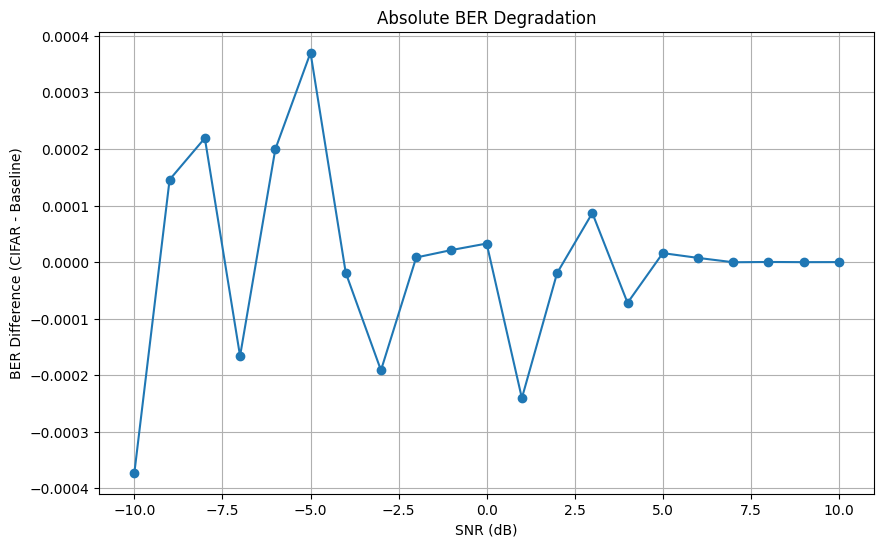

In [10]:
diff = []

for b, c in zip(baseline_ber, cifar_ber):
    if b is not None and c is not None:
        diff.append(c - b)
    else:
        diff.append(None)

plt.figure(figsize=(10,6))
plt.plot(snr_vals, diff, marker='o')

plt.xlabel("SNR (dB)")
plt.ylabel("BER Difference (CIFAR - Baseline)")
plt.title("Absolute BER Degradation")
plt.grid(True)

plt.show()

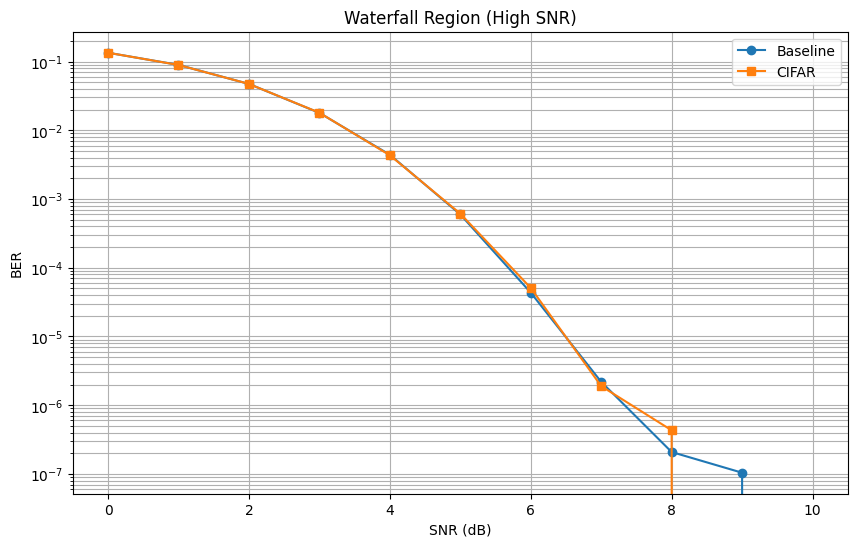

In [11]:
plt.figure(figsize=(10,6))

high_snr = [i for i in range(len(snr_vals)) if snr_vals[i] >= 0]

plt.plot(np.array(snr_vals)[high_snr], np.array(baseline_ber)[high_snr], marker='o', label="Baseline")
plt.plot(np.array(snr_vals)[high_snr], np.array(cifar_ber)[high_snr], marker='s', label="CIFAR")

plt.yscale("log")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("Waterfall Region (High SNR)")
plt.grid(True, which="both")
plt.legend()

plt.show()

In [12]:
def find_snr_for_ber(target_ber, snrs, bers):
    for i in range(len(bers)):
        if bers[i] is not None and bers[i] <= target_ber:
            return snrs[i]
    return None

target_bers = [1e-1, 1e-2, 1e-3, 1e-4]

print("SNR Gap Analysis:")
for tb in target_bers:
    snr_baseline = find_snr_for_ber(tb, snr_vals, baseline_ber)
    snr_cifar = find_snr_for_ber(tb, snr_vals, cifar_ber)

    if snr_baseline is not None and snr_cifar is not None:
        print(f"BER={tb}: ΔSNR = {snr_cifar - snr_baseline} dB")

SNR Gap Analysis:
BER=0.1: ΔSNR = 0 dB
BER=0.01: ΔSNR = 0 dB
BER=0.001: ΔSNR = 0 dB
BER=0.0001: ΔSNR = 0 dB
